# Phase 2: Exploratory Data Analysis (EDA)

Includes:

- Target Variable Analysis  
- Numerical Feature Distribution  
- Numerical Features vs Churn  
- Categorical Features vs Churn  
- Correlation Analysis  
- Feature Importance  
- Cohort Tenure (retention/churn by cohort)  
- EDA Insight Summary  

In [1]:
import os
import json
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

warnings.filterwarnings("ignore")

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

def create_folders():
    os.makedirs("artifacts/data", exist_ok=True)
    os.makedirs("artifacts/results", exist_ok=True)
    os.makedirs("artifacts/models", exist_ok=True)
    os.makedirs("artifacts/figures", exist_ok=True)

def save_figure(fig, filename, folder="artifacts/figures", dpi=300):
    Path(folder).mkdir(parents=True, exist_ok=True)
    fig.savefig(Path(folder) / filename, dpi=dpi, bbox_inches="tight")

set_seed()
create_folders()

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

In [2]:
# Load Prepared Data for EDA
df = pd.read_csv("artifacts/data/df_clean.csv")

with open("artifacts/data/meta.json", "r", encoding="utf-8") as f:
    meta = json.load(f)

TARGET_COL = meta["TARGET_COL"]
CATEGORICAL_COLS = meta["CATEGORICAL_COLS"]
NUMERIC_COLS = meta["NUMERIC_COLS"]

print("Dataset shape:", df.shape)
print("Target column:", TARGET_COL)
print("Number of categorical columns:", len(CATEGORICAL_COLS))
print("Number of numerical columns:", len(NUMERIC_COLS))

df.head()

Dataset shape: (5067, 18)
Target column: Churn
Number of categorical columns: 6
Number of numerical columns: 11


,PreferredLoginDevice,PreferredPaymentMode,Gender,PreferedOrderCat,MaritalStatus,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,Churn
0,Mobile Phone,Debit Card,Female,Laptop & Accessory,Single,3,6.0,3.0,3,2,9,1,11.0,1.0,1.0,5.0,160,1
1,Mobile Phone,UPI,Male,Mobile,Single,1,8.0,3.0,4,3,7,1,15.0,0.0,1.0,0.0,121,1
2,Mobile Phone,Debit Card,Male,Mobile,Single,1,30.0,2.0,4,3,6,1,14.0,0.0,1.0,3.0,120,1
3,Mobile Phone,Debit Card,Male,Laptop & Accessory,Single,3,15.0,2.0,4,5,8,0,23.0,0.0,1.0,3.0,134,1
4,Mobile Phone,Credit Card,Male,Mobile,Single,1,12.0,NaN,3,5,3,0,11.0,1.0,1.0,3.0,130,1


**1. Target Variable Analysis**

In [3]:
print("Shape:", df.shape)
display(df.head())

print("\nInfo:")
display(df.info())

print("\nDescribe (numeric):")
display(df[NUMERIC_COLS].describe().T)

Shape: (5067, 18)


,PreferredLoginDevice,PreferredPaymentMode,Gender,PreferedOrderCat,MaritalStatus,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,Churn
0,Mobile Phone,Debit Card,Female,Laptop & Accessory,Single,3,6.0,3.0,3,2,9,1,11.0,1.0,1.0,5.0,160,1
1,Mobile Phone,UPI,Male,Mobile,Single,1,8.0,3.0,4,3,7,1,15.0,0.0,1.0,0.0,121,1
2,Mobile Phone,Debit Card,Male,Mobile,Single,1,30.0,2.0,4,3,6,1,14.0,0.0,1.0,3.0,120,1
3,Mobile Phone,Debit Card,Male,Laptop & Accessory,Single,3,15.0,2.0,4,5,8,0,23.0,0.0,1.0,3.0,134,1
4,Mobile Phone,Credit Card,Male,Mobile,Single,1,12.0,NaN,3,5,3,0,11.0,1.0,1.0,3.0,130,1



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5067 entries, 0 to 5066
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   PreferredLoginDevice         5067 non-null   object 
 1   PreferredPaymentMode         5067 non-null   object 
 2   Gender                       5067 non-null   object 
 3   PreferedOrderCat             5067 non-null   object 
 4   MaritalStatus                5067 non-null   object 
 5   CityTier                     5067 non-null   int64  
 6   WarehouseToHome              4846 non-null   float64
 7   HourSpendOnApp               4838 non-null   float64
 8   NumberOfDeviceRegistered     5067 non-null   int64  
 9   SatisfactionScore            5067 non-null   int64  
 10  NumberOfAddress              5067 non-null   int64  
 11  Complain                     5067 non-null   int64  
 12  OrderAmountHikeFromlastYear  4815 non-null   float64
 13  CouponUsed 

None


Describe (numeric):


,count,mean,std,min,25%,50%,75%,max
WarehouseToHome,4846.0,15.534461,8.593512,5.0,9.0,13.0,20.0,127.0
HourSpendOnApp,4838.0,2.929103,0.723892,0.0,2.0,3.0,3.0,5.0
NumberOfDeviceRegistered,5067.0,3.686600,1.029022,1.0,3.0,4.0,4.0,6.0
SatisfactionScore,5067.0,3.027630,1.384601,1.0,2.0,3.0,4.0,5.0
NumberOfAddress,5067.0,4.194790,2.580284,1.0,2.0,3.0,6.0,22.0
Complain,5067.0,0.282416,0.450219,0.0,0.0,0.0,1.0,1.0
OrderAmountHikeFromlastYear,4815.0,15.712773,3.682670,11.0,13.0,15.0,18.0,26.0
CouponUsed,4858.0,1.806711,1.947822,0.0,1.0,1.0,2.0,16.0
OrderCount,4824.0,3.095978,2.996666,1.0,1.0,2.0,3.0,16.0
DaySinceLastOrder,4779.0,4.582967,3.663820,0.0,2.0,3.0,7.0,46.0


In [4]:
assert TARGET_COL in df.columns, f"{TARGET_COL} not found in df"

# 1) Counts & ratio
counts = df[TARGET_COL].value_counts().sort_index()
ratios = df[TARGET_COL].value_counts(normalize=True).sort_index()

print("\nClass Counts:")
display(counts)

print("\nClass Ratio:")
display(ratios)

churn_pct = ratios.get(1, np.nan) * 100
nonchurn_pct = ratios.get(0, np.nan) * 100
print(f"\nChurn Percentage: {churn_pct:.2f}%")
print(f"Non-churn Percentage: {nonchurn_pct:.2f}%")


Class Counts:


Churn
0    4228
1     839
Name: count, dtype: int64


Class Ratio:


Churn
0    0.834419
1    0.165581
Name: proportion, dtype: float64


Churn Percentage: 16.56%
Non-churn Percentage: 83.44%


In [5]:
plt.style.use("default")
sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "figure.figsize": (7, 5),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

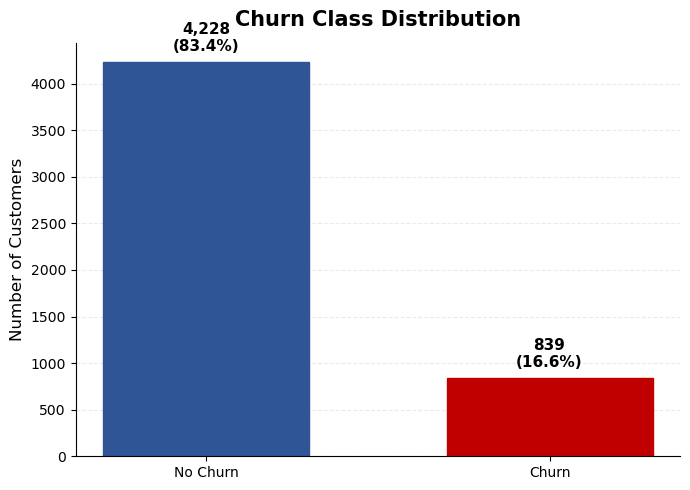

In [6]:
counts = df[TARGET_COL].value_counts().sort_index()
ratios = df[TARGET_COL].value_counts(normalize=True).sort_index()

labels = ["No Churn", "Churn"]
values = counts.values
percentages = ratios.values * 100

# Clean white theme
plt.style.use("default")

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(labels, values, width=0.6)

# Professional academic color palette
colors = ["#2F5597", "#C00000"]  # deep blue & deep red
for bar, color in zip(bars, colors):
    bar.set_color(color)

# Remove top/right borders (clean look)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Light horizontal grid only
ax.yaxis.grid(True, linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

# Titles & labels
ax.set_title("Churn Class Distribution", fontsize=15, fontweight="bold", pad=12)
ax.set_ylabel("Number of Customers", fontsize=12)

# Annotate values + percentages
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + max(values)*0.02,
        f"{values[i]:,}\n({percentages[i]:.1f}%)",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

***
Biểu đồ cho thấy sự phân bố giữa hai nhóm khách hàng trong tập dữ liệu là **không cân bằng**. Cụ thể, nhóm **không rời bỏ (No Churn)** gồm **4.228 khách hàng**, chiếm **83,4%**, trong khi nhóm **rời bỏ (Churn)** chỉ có **839 khách hàng**, tương ứng **16,6%**.

Sự chênh lệch này phản ánh rằng lớp đa số là nhóm khách hàng không rời bỏ, còn lớp khách hàng rời bỏ chiếm tỷ lệ thấp hơn đáng kể. Đây là một đặc điểm thường gặp trong các bài toán dự đoán churn và có thể khiến mô hình học máy dễ thiên về lớp đa số nếu chỉ đánh giá bằng các chỉ số đơn giản như accuracy.

Vì vậy, trong nghiên cứu này cần ưu tiên các thước đo đánh giá phù hợp với dữ liệu mất cân bằng như **F1-score**, **Recall**, **ROC-AUC** và **PR-AUC**, nhằm phản ánh chính xác hơn khả năng nhận diện khách hàng có nguy cơ rời bỏ.
***

**2. Numerical Feature Distribution** 

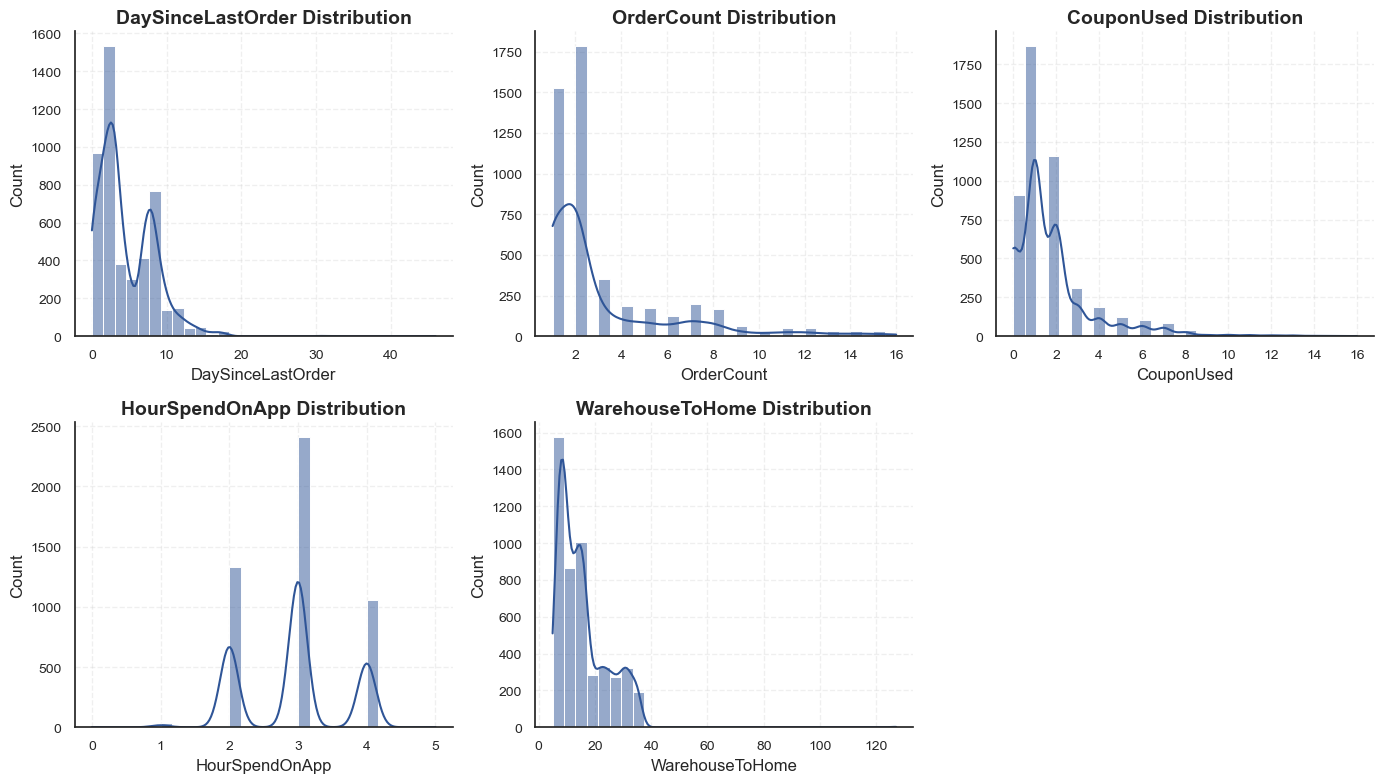

In [58]:
important_numeric = [
    "DaySinceLastOrder",
    "OrderCount",
    "CouponUsed",
    "HourSpendOnApp",
    "WarehouseToHome",
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(important_numeric):
    sns.histplot(
        df[col],
        bins=30,
        kde=True,
        ax=axes[i],
        color="#2F5597"
    )
    
    axes[i].set_title(f"{col} Distribution", fontweight="bold")
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].grid(True, linestyle="--", alpha=0.3)
for j in range(len(important_numeric), len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

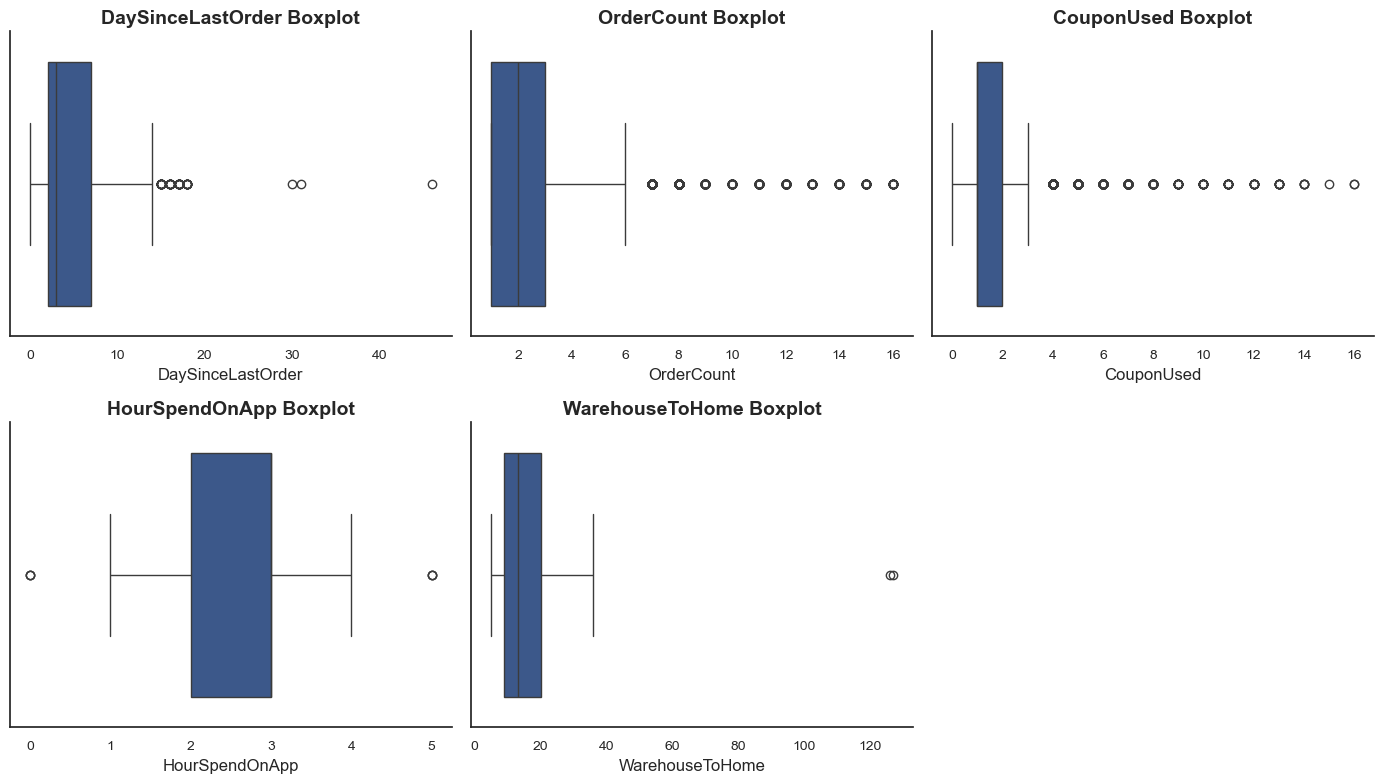

In [57]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(important_numeric):
    sns.boxplot(
        x=df[col],
        ax=axes[i],
        color="#2F5597"
    )
    
    axes[i].set_title(f"{col} Boxplot", fontweight="bold")
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
for j in range(len(important_numeric), len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

In [12]:
skewness = df[important_numeric].skew().sort_values(ascending=False)
print("Skewness of selected numerical features:")
display(skewness)

Skewness of selected numerical features:


CouponUsed           2.458662
OrderCount           2.102419
WarehouseToHome      1.699777
DaySinceLastOrder    1.218114
HourSpendOnApp      -0.029536
dtype: float64

***
Kết quả đo độ lệch (skewness) cho thấy phần lớn các biến hành vi trong tập dữ liệu có **phân phối lệch phải**. Cụ thể, biến **CouponUsed** có độ lệch cao nhất (**2,458662**), tiếp theo là **OrderCount** (**2,102419**), **WarehouseToHome** (**1,699777**) và **DaySinceLastOrder** (**1,218114**). Điều này cho thấy phần lớn khách hàng tập trung ở các mức giá trị thấp, trong khi chỉ một nhóm nhỏ có giá trị rất cao.

Đặc biệt, biến **DaySinceLastOrder** có độ lệch phải khá rõ, phản ánh sự tồn tại của một nhóm khách hàng có thời gian không phát sinh đơn hàng trong thời gian dài. Đây có thể là dấu hiệu cho thấy mức độ tương tác suy giảm trước khi khách hàng rời bỏ.

Trong khi đó, biến **HourSpendOnApp** có độ lệch **-0,029536**, tức là gần bằng 0, cho thấy phân phối của biến này tương đối cân đối và ổn định hơn so với các biến còn lại.

Sự tồn tại của các phân phối lệch và khả năng xuất hiện các giá trị ngoại lai cho thấy dữ liệu hành vi khách hàng có tính không đối xứng khá rõ. Đặc điểm này cũng gợi ý rằng mối quan hệ giữa các biến hành vi và khả năng rời bỏ có thể mang tính phi tuyến, từ đó củng cố cơ sở cho việc sử dụng các mô hình có khả năng học tốt trên dữ liệu bảng như **TabNet**, cũng như các mô hình học máy phi tuyến khác trong nghiên cứu.
***

**3. Numerical Features vs Churn** 

In [13]:
mean_comparison = df.groupby(TARGET_COL)[important_numeric].mean().T
mean_comparison.columns = ["No Churn", "Churn"]
display(mean_comparison)

,No Churn,Churn
DaySinceLastOrder,4.829952,3.328244
OrderCount,3.125719,2.951397
CouponUsed,1.808648,1.797362
HourSpendOnApp,2.925167,2.949303
WarehouseToHome,15.268759,16.945312


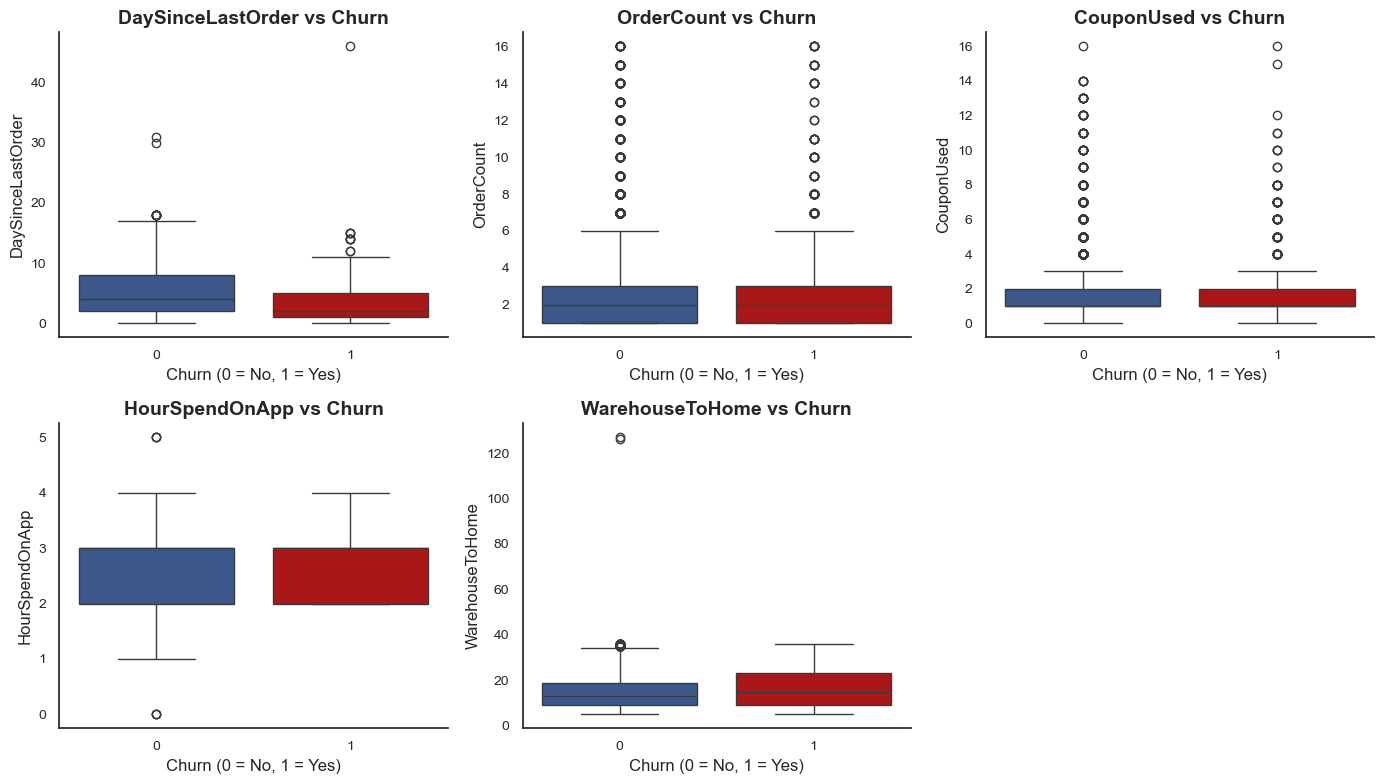

In [55]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(important_numeric):
    sns.boxplot(
        x=df[TARGET_COL],
        y=df[col],
        ax=axes[i],
        palette=["#2F5597", "#C00000"]
    )
    
    axes[i].set_title(f"{col} vs Churn", fontweight="bold")
    axes[i].set_xlabel("Churn (0 = No, 1 = Yes)")
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
for j in range(len(important_numeric), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

***
Biểu đồ hộp cho thấy một số biến có sự khác biệt nhất định giữa nhóm khách hàng rời bỏ và không rời bỏ, mặc dù mức độ tách biệt chưa hoàn toàn rõ ràng khi xét riêng lẻ từng biến.

Đối với **DaySinceLastOrder**, nhóm khách hàng churn có trung vị thấp hơn nhẹ so với nhóm không churn, tuy nhiên vẫn xuất hiện nhiều giá trị ngoại lai ở cả hai nhóm. Điều này cho thấy biến này có sự phân tán khá lớn và có thể chứa thông tin hữu ích, nhưng chưa tạo ra ranh giới tách biệt mạnh khi quan sát đơn biến.

Với **OrderCount** và **CouponUsed**, phân phối của hai nhóm khá tương đồng, trung vị gần nhau và vùng tứ phân vị chồng lấn đáng kể. Điều đó cho thấy nếu xét độc lập, hai biến này chưa cho thấy khác biệt rõ rệt giữa khách hàng churn và không churn, dù vẫn tồn tại nhiều ngoại lai ở mức giá trị cao.

Đối với **HourSpendOnApp**, phân phối giữa hai nhóm gần như tương tự nhau, với trung vị xấp xỉ nhau và độ phân tán không quá khác biệt. Điều này hàm ý rằng thời gian sử dụng ứng dụng, khi xét riêng lẻ, có thể chưa phải là biến phân biệt mạnh trạng thái churn.

Trong khi đó, **WarehouseToHome** cho thấy nhóm churn có xu hướng có trung vị cao hơn so với nhóm không churn, đồng thời khoảng phân bố cũng nhỉnh hơn. Kết quả này gợi ý rằng khoảng cách từ kho đến nơi ở của khách hàng có thể liên quan đến khả năng rời bỏ, có thể do ảnh hưởng đến trải nghiệm giao hàng hoặc mức độ thuận tiện khi mua sắm.

Các biểu đồ hộp cho thấy phần lớn biến số vẫn có sự chồng lấn đáng kể giữa hai nhóm khách hàng, cho thấy hiện tượng churn khó có thể được giải thích đầy đủ chỉ bằng từng biến riêng lẻ. Điều này cũng củng cố sự cần thiết của các mô hình học máy có khả năng khai thác đồng thời nhiều biến và học các quan hệ phi tuyến, thay vì chỉ dựa trên phân tích đơn biến.
***

In [15]:
def cohens_d(x0, x1):
    mean_diff = x1.mean() - x0.mean()
    pooled_std = np.sqrt((x0.std()**2 + x1.std()**2) / 2)
    return mean_diff / pooled_std

effect_sizes = {}

for col in important_numeric:
    group0 = df[df[TARGET_COL] == 0][col]
    group1 = df[df[TARGET_COL] == 1][col]
    effect_sizes[col] = cohens_d(group0, group1)

effect_df = pd.DataFrame.from_dict(effect_sizes, orient='index', columns=["Cohen_d"])
display(effect_df.sort_values("Cohen_d", key=abs, ascending=False))

,Cohen_d
DaySinceLastOrder,-0.421758
WarehouseToHome,0.194703
OrderCount,-0.058939
HourSpendOnApp,0.033891
CouponUsed,-0.005766


***
The effect size values (Cohen’s d) indicate that several variables exhibit moderate to large differences, suggesting that the relationship between transactional behavior and churn probability is not purely random.

The presence of nonlinear distributions and complex behavioral interactions among features further reinforces the rationale for adopting specialized deep learning models for tabular data, such as TabNet, in the modeling phase.
***

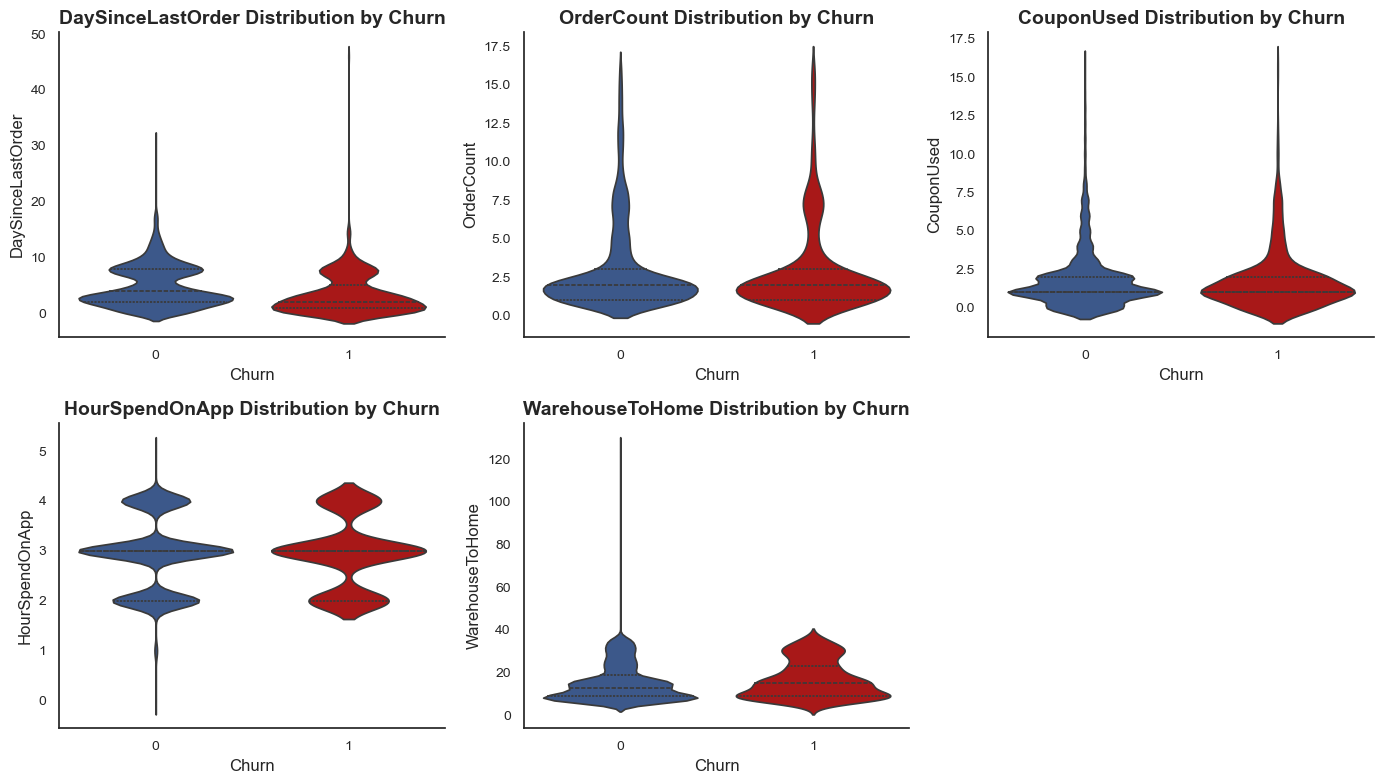

In [56]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(important_numeric):
    sns.violinplot(
        x=df[TARGET_COL],
        y=df[col],
        ax=axes[i],
        palette=["#2F5597", "#C00000"],
        inner="quartile"
    )
    
    axes[i].set_title(f"{col} Distribution by Churn", fontweight="bold")
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
for j in range(len(important_numeric), len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

***
Biểu đồ violin cho thấy phân phối của các biến giữa hai nhóm khách hàng churn và không churn có sự khác biệt nhất định, nhưng nhìn chung vẫn còn chồng lấn khá nhiều. Điều này cho thấy hành vi rời bỏ không bị chi phối bởi một biến riêng lẻ, mà nhiều khả năng hình thành từ sự kết hợp của nhiều yếu tố.

Với **DaySinceLastOrder**, nhóm khách hàng churn có xu hướng tập trung nhiều ở các mức thấp, đồng thời vẫn tồn tại phần đuôi kéo dài về phía các giá trị cao. So với nhóm không churn, phân phối của nhóm churn có sự khác biệt nhưng chưa thực sự tách biệt hoàn toàn. Biến này vì vậy vẫn có giá trị giải thích nhất định đối với khả năng rời bỏ.

Đối với **OrderCount** và **CouponUsed**, hình dạng phân phối của hai nhóm khá giống nhau. Phần lớn quan sát đều tập trung ở các mức thấp, trong khi một số ít trường hợp kéo dài lên các giá trị cao hơn. Điều này cho thấy hai biến này có thể phản ánh hành vi mua sắm và sử dụng ưu đãi của khách hàng, tuy nhiên nếu xét riêng lẻ thì khả năng phân biệt giữa hai nhóm chưa thật sự rõ.

Biến **HourSpendOnApp** có phân phối tương đối tương đồng giữa khách hàng churn và không churn. Mật độ quan sát chủ yếu tập trung quanh các mức sử dụng trung bình, cho thấy thời gian sử dụng ứng dụng, khi đứng một mình, chưa phải là tín hiệu quá mạnh để nhận diện khả năng rời bỏ.

Trong số các biến được quan sát, **WarehouseToHome** là biến thể hiện sự khác biệt rõ hơn. Nhóm khách hàng churn có xu hướng phân bố ở các mức cao hơn so với nhóm không churn, hàm ý rằng khoảng cách từ kho đến nơi ở có thể ảnh hưởng đến trải nghiệm mua sắm, thời gian giao hàng và cuối cùng là quyết định tiếp tục hay rời bỏ nền tảng.

Tổng thể, biểu đồ violin cho thấy các biến đều mang một mức độ thông tin nhất định, nhưng chưa có biến nào đủ sức tách biệt hoàn toàn hai nhóm khách hàng. Kết quả này củng cố thêm cho việc sử dụng các mô hình học máy có khả năng khai thác đồng thời nhiều đặc trưng và học được các quan hệ phi tuyến trong bài toán dự đoán churn.
***

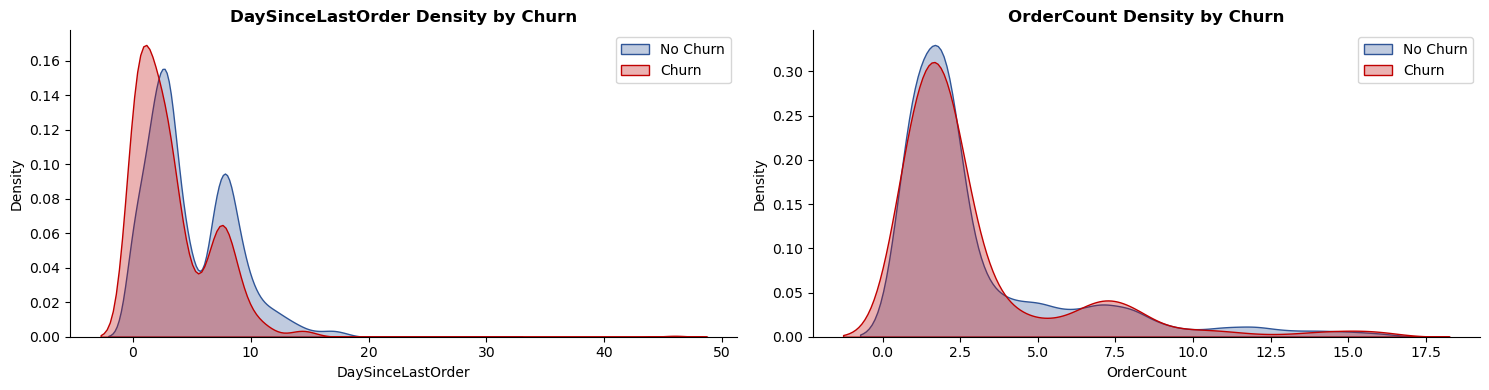

In [18]:
selected = [ "DaySinceLastOrder", "OrderCount"]

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

for i, col in enumerate(selected):
    sns.kdeplot(
        df[df[TARGET_COL] == 0][col],
        ax=axes[i],
        label="No Churn",
        color="#2F5597",
        fill=True,
        alpha=0.3
    )
    
    sns.kdeplot(
        df[df[TARGET_COL] == 1][col],
        ax=axes[i],
        label="Churn",
        color="#C00000",
        fill=True,
        alpha=0.3
    )
    
    axes[i].set_title(f"{col} Density by Churn", fontweight="bold")
    axes[i].legend()
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

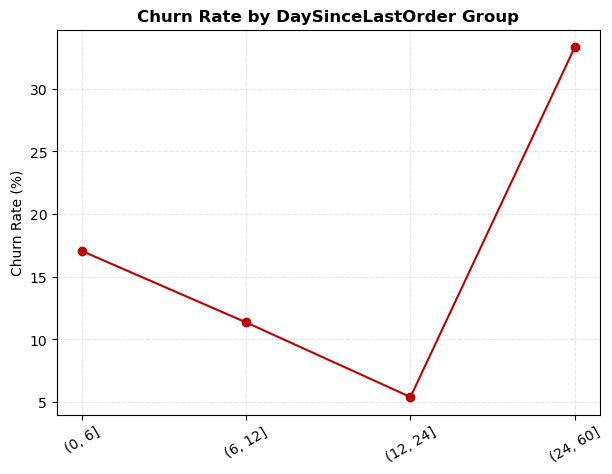

In [19]:
df["DaySinceLastOrder_bin"] = pd.cut(df["DaySinceLastOrder"], bins=[0,6,12,24,60])

churn_by_tenure = df.groupby("DaySinceLastOrder_bin")[TARGET_COL].mean() * 100

plt.figure(figsize=(7,5))
plt.plot(churn_by_tenure.index.astype(str), churn_by_tenure.values, marker="o", color="#C00000")

plt.title("Churn Rate by DaySinceLastOrder Group", fontweight="bold")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30)
plt.grid(True, linestyle="--", alpha=0.3)

plt.show()

***
Biểu đồ cho thấy tỷ lệ churn thay đổi khá rõ giữa các nhóm **DaySinceLastOrder**. Cụ thể, nhóm khách hàng có số ngày kể từ lần đặt hàng gần nhất trong khoảng **(12, 24]** có tỷ lệ churn thấp nhất, chỉ khoảng **5%**. Trong khi đó, nhóm **(24, 60]** lại có tỷ lệ churn cao nhất, lên tới khoảng **33%**.

Ngoài ra, hai nhóm **(0, 6]** và **(6, 12]** có tỷ lệ churn lần lượt vào khoảng **17%** và **11%**, cho thấy xu hướng giảm dần ở các khoảng đầu trước khi tăng mạnh ở nhóm có thời gian không mua hàng kéo dài nhất.

Kết quả này cho thấy **DaySinceLastOrder** có mối liên hệ đáng chú ý với hành vi rời bỏ. Đặc biệt, khi khoảng thời gian kể từ lần mua gần nhất tăng lên mức cao, nguy cơ churn cũng tăng mạnh. Điều này hàm ý rằng những khách hàng đã lâu không phát sinh đơn hàng là nhóm cần được ưu tiên theo dõi và triển khai các chương trình giữ chân phù hợp.

Nhìn chung, biến **DaySinceLastOrder** không chỉ có ý nghĩa mô tả hành vi mua sắm gần đây mà còn có tiềm năng trở thành một biến dự báo quan trọng trong mô hình churn prediction.
***

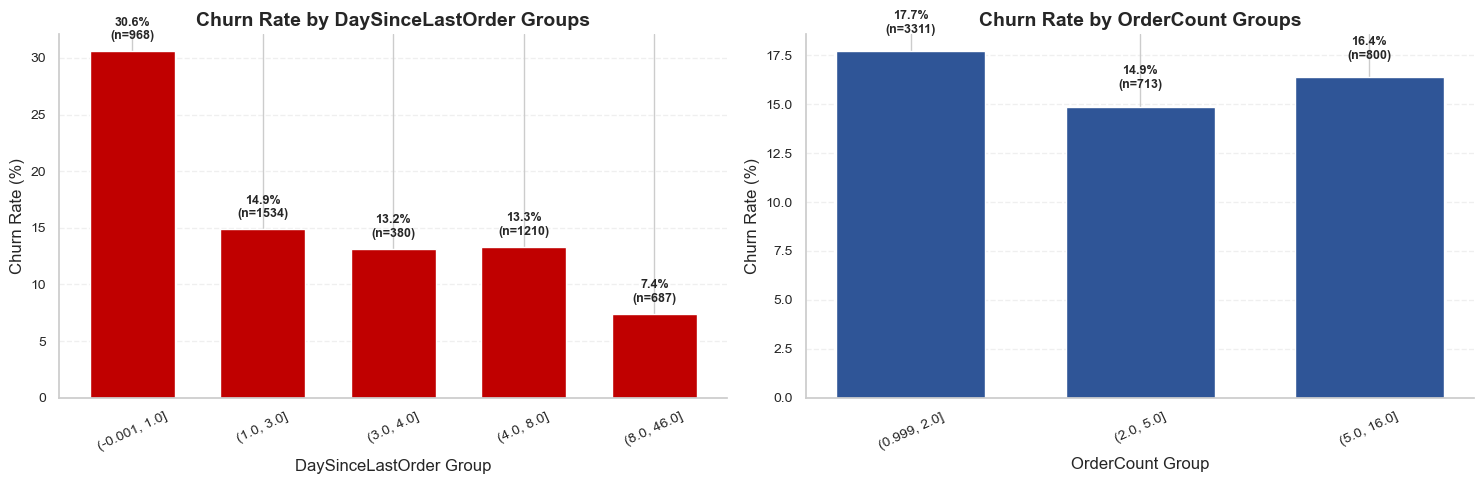

In [23]:
plt.style.use("default")
sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def get_binned_churn_summary(data, feature, target_col="Churn", bins=5, method="quantile"):
    df_plot = data[[feature, target_col]].copy().dropna()

    if method == "quantile":
        df_plot[f"{feature}_bin"] = pd.qcut(
            df_plot[feature],
            q=bins,
            duplicates="drop"
        )
    else:
        df_plot[f"{feature}_bin"] = pd.cut(
            df_plot[feature],
            bins=bins
        )

    summary = (
        df_plot.groupby(f"{feature}_bin", observed=False)[target_col]
        .agg(["count", "mean"])
        .reset_index()
    )

    summary["Churn Rate (%)"] = summary["mean"] * 100
    summary["bin_label"] = summary[f"{feature}_bin"].astype(str)

    return summary

def plot_binned_churn_rate(ax, summary, feature_name, color):
    bars = ax.bar(
        summary["bin_label"],
        summary["Churn Rate (%)"],
        color=color,
        width=0.65
    )

    ax.set_title(f"Churn Rate by {feature_name} Groups")
    ax.set_xlabel(f"{feature_name} Group")
    ax.set_ylabel("Churn Rate (%)")
    ax.grid(True, axis="y", linestyle="--", alpha=0.3)
    ax.tick_params(axis="x", rotation=25)

    for i, bar in enumerate(bars):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f"{bar.get_height():.1f}%\n(n={summary.loc[i, 'count']})",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

# Create summaries
daysince_summary = get_binned_churn_summary(df, "DaySinceLastOrder", TARGET_COL, bins=5)
ordercount_summary = get_binned_churn_summary(df, "OrderCount", TARGET_COL, bins=5)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_binned_churn_rate(
    axes[0],
    daysince_summary,
    feature_name="DaySinceLastOrder",
    color="#C00000"
)

plot_binned_churn_rate(
    axes[1],
    ordercount_summary,
    feature_name="OrderCount",
    color="#2F5597"
)

plt.tight_layout()
plt.show()

In [25]:
print("OrderCount summary")
display(ordercount_summary[["bin_label", "count", "Churn Rate (%)"]])

OrderCount summary


,bin_label,count,Churn Rate (%)
0,"(0.999, 2.0]",3311,17.69858
1,"(2.0, 5.0]",713,14.86676
2,"(5.0, 16.0]",800,16.37500


In [26]:
print("DaySinceLastOrder summary")
display(lastorder_summary[["bin_label", "count", "Churn Rate (%)"]])

DaySinceLastOrder summary


,bin_label,count,Churn Rate (%)
0,"(-0.001, 1.0]",968,30.578512
1,"(1.0, 3.0]",1534,14.863103
2,"(3.0, 4.0]",380,13.157895
3,"(4.0, 8.0]",1210,13.305785
4,"(8.0, 46.0]",687,7.423581


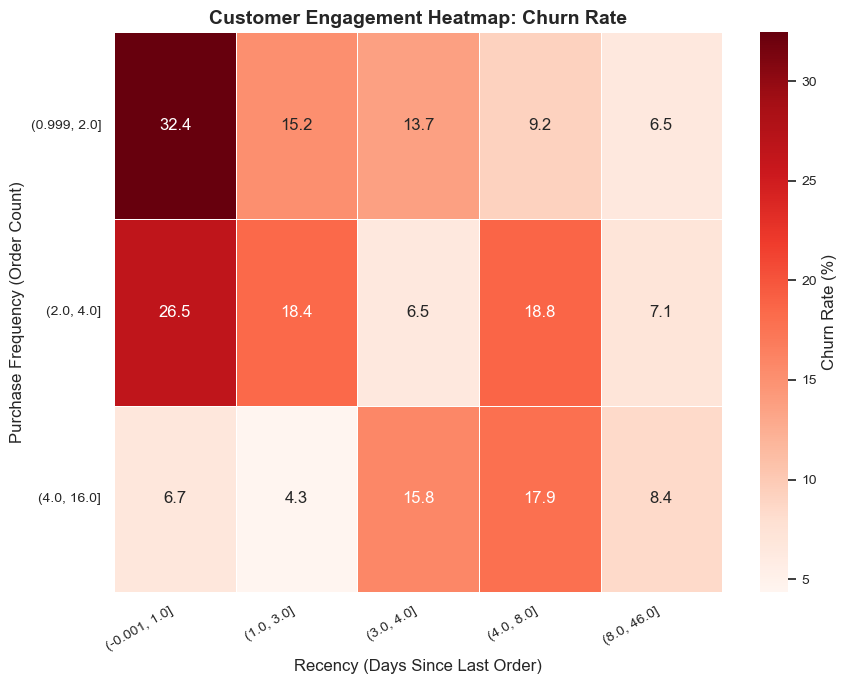

In [27]:
plt.style.use("default")
sns.set_theme(style="white")

plt.rcParams.update({
    "figure.figsize": (8, 6),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})


heat_df = df[["OrderCount", "DaySinceLastOrder", TARGET_COL]].dropna().copy()

# Bin both features (quantile-based)
heat_df["Order_bin"] = pd.qcut(
    heat_df["OrderCount"],
    q=5,
    duplicates="drop"
)

heat_df["Recency_bin"] = pd.qcut(
    heat_df["DaySinceLastOrder"],
    q=5,
    duplicates="drop"
)

# Compute churn rate matrix
pivot_table = heat_df.pivot_table(
    index="Order_bin",
    columns="Recency_bin",
    values=TARGET_COL,
    aggfunc="mean"
)

pivot_table = pivot_table * 100  # convert to %


plt.figure(figsize=(9, 7))

ax = sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".1f",
    cmap="Reds",
    cbar_kws={"label": "Churn Rate (%)"},
    linewidths=0.5,
    linecolor="white"
)

plt.title("Customer Engagement Heatmap: Churn Rate")
plt.xlabel("Recency (Days Since Last Order)")
plt.ylabel("Purchase Frequency (Order Count)")

plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

***
Heatmap cho thấy tỷ lệ churn thay đổi đáng kể khi xét đồng thời **tần suất mua hàng (Order Count)** và **mức độ gần đây của lần mua gần nhất (DaySinceLastOrder)**. Kết quả này cho thấy hành vi rời bỏ không phụ thuộc vào một biến đơn lẻ mà chịu ảnh hưởng từ sự kết hợp giữa nhiều khía cạnh của mức độ tương tác khách hàng.

Dễ thấy nhất là nhóm khách hàng có **tần suất mua thấp** từ **1 đến 2 đơn** và có lần mua gần nhất trong khoảng **0 đến 1 ngày** đang có tỷ lệ churn cao nhất, lên tới **32,4%**. Nhóm khách hàng mua từ **2 đến 4 đơn** trong cùng khoảng thời gian này cũng có tỷ lệ churn khá cao, ở mức **26,5%**. Điều này cho thấy dù khách hàng vừa mới phát sinh giao dịch, nhưng nếu tần suất mua nhìn chung còn thấp thì nguy cơ rời bỏ vẫn lớn.

Ngược lại, nhóm khách hàng có **tần suất mua cao hơn** từ **4 đến 16 đơn** và có lần mua gần nhất trong khoảng **1 đến 3 ngày** lại có tỷ lệ churn thấp nhất, chỉ khoảng **4,3%**. Kết quả này gợi ý rằng những khách hàng mua thường xuyên và vẫn duy trì tương tác gần đây có xu hướng ổn định hơn và ít rời bỏ hơn.

Một điểm đáng chú ý khác là tỷ lệ churn **không giảm hay tăng hoàn toàn tuyến tính** theo từng nhóm. Chẳng hạn, ở nhóm khách hàng mua nhiều hơn, tỷ lệ churn lại tăng lên ở các khoảng recency trung bình như **3–4 ngày** (**15,8%**) và **4–8 ngày** (**17,9%**). Điều này cho thấy mối quan hệ giữa hành vi mua hàng và churn khá phức tạp, có thể tồn tại sự tương tác giữa tần suất mua, độ mới của giao dịch và các đặc điểm khác của khách hàng.

Nhìn chung, heatmap này cho thấy **Purchase Frequency** và **DaySinceLastOrder** đều là những biến có ý nghĩa trong bài toán dự đoán churn. Quan trọng hơn, biểu đồ cũng gợi ý rằng việc kết hợp nhiều biến hành vi cùng lúc sẽ giúp phản ánh rủi ro rời bỏ tốt hơn so với việc xem xét từng biến riêng lẻ.
***

**4. Categorical Features vs Churn** 

In [28]:
categorical_cols = CATEGORICAL_COLS

for col in categorical_cols:
    print(f"\n===== {col} =====")
    
    churn_rate = (
        df.groupby(col)[TARGET_COL]
        .mean()
        .sort_values(ascending=False) * 100
    )
    
    display(churn_rate.round(2))


===== PreferredLoginDevice =====


PreferredLoginDevice
Computer        19.48
Mobile Phone    15.38
Name: Churn, dtype: float64


===== PreferredPaymentMode =====


PreferredPaymentMode
Cash on Delivery    25.38
E-wallet            22.78
UPI                 15.56
Debit Card          14.96
Credit Card         14.16
Name: Churn, dtype: float64


===== Gender =====


...

PreferedOrderCat
Mobile Phone          26.48
Mobile                26.07
Fashion               16.25
Laptop & Accessory    10.42
Others                 7.85
Grocery                4.38
Name: Churn, dtype: float64


===== MaritalStatus =====


MaritalStatus
Single      26.63
Divorced    14.62
Married     11.32
Name: Churn, dtype: float64


===== CityTier =====


CityTier
3    21.95
2    17.44
1    13.94
Name: Churn, dtype: float64

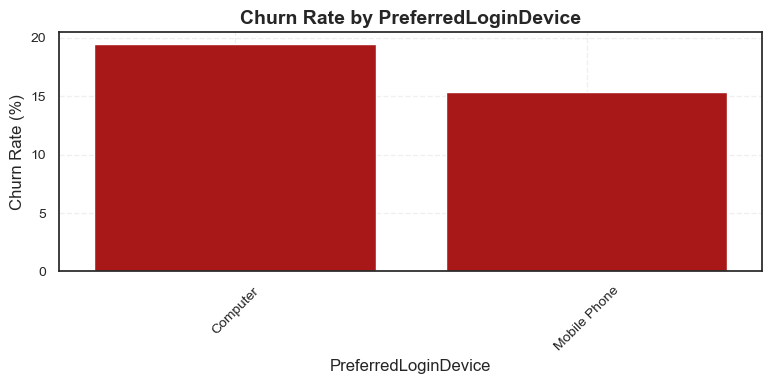

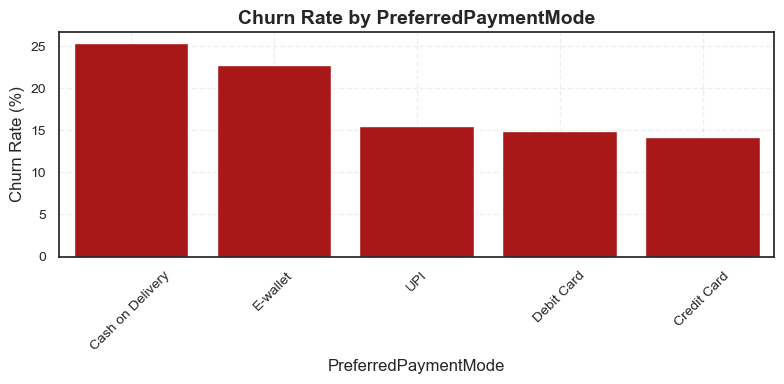

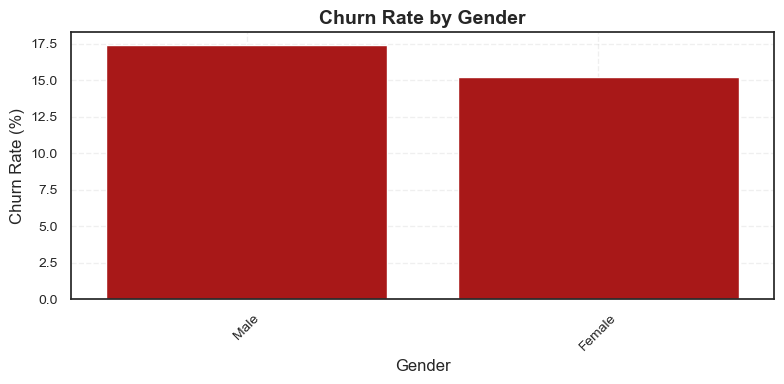

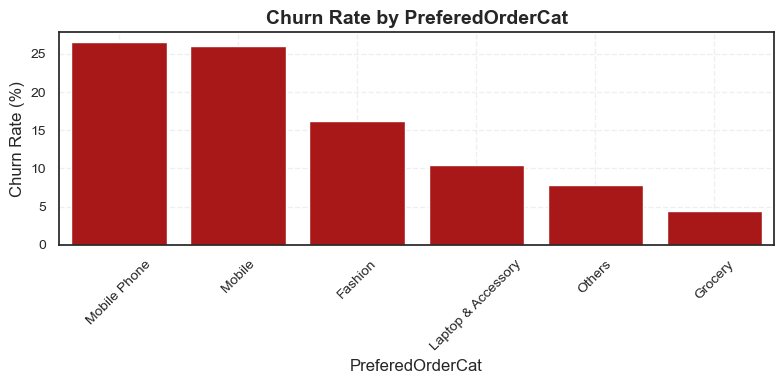

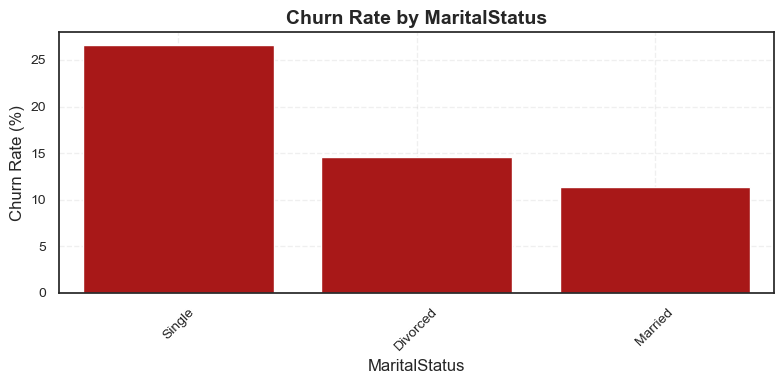

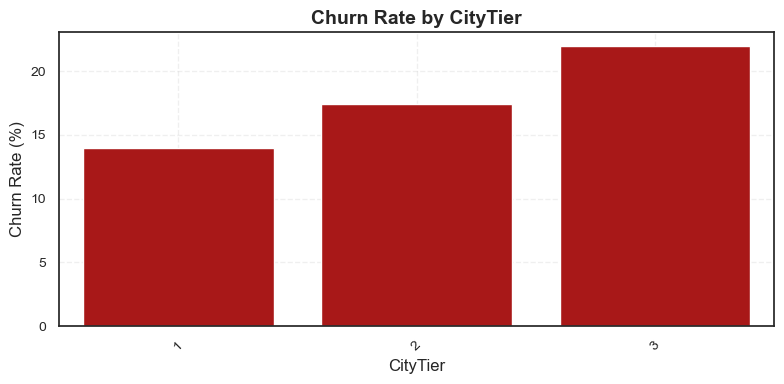

In [29]:
for col in categorical_cols:
    
    churn_rate = (
        df.groupby(col)[TARGET_COL]
        .mean()
        .sort_values(ascending=False) * 100
    )
    
    plt.figure(figsize=(8, 4))
    
    sns.barplot(
        x=churn_rate.index,
        y=churn_rate.values,
        color="#C00000"
    )
    
    plt.title(f"Churn Rate by {col}", fontweight="bold")
    plt.ylabel("Churn Rate (%)")
    plt.xticks(rotation=45)
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

In [30]:
for col in categorical_cols:
    print(f"\n===== Distribution within {col} =====")
    
    crosstab = pd.crosstab(
        df[col],
        df[TARGET_COL],
        normalize='index'
    )
    
    display((crosstab * 100).round(2))


===== Distribution within PreferredLoginDevice =====


Churn,0,1
PreferredLoginDevice,,
Computer,80.52,19.48
Mobile Phone,84.62,15.38



===== Distribution within PreferredPaymentMode =====


Churn,0,1
PreferredPaymentMode,,
Cash on Delivery,74.62,25.38
Credit Card,85.84,14.16
Debit Card,85.04,14.96
E-wallet,77.22,22.78
UPI,84.44,15.56



===== Distribution within Gender =====


...

Churn,0,1
PreferedOrderCat,,
Fashion,83.75,16.25
Grocery,95.62,4.38
Laptop & Accessory,89.58,10.42
Mobile,73.93,26.07
Mobile Phone,73.52,26.48
Others,92.15,7.85



===== Distribution within MaritalStatus =====


Churn,0,1
MaritalStatus,,
Divorced,85.38,14.62
Married,88.68,11.32
Single,73.37,26.63



===== Distribution within CityTier =====


Churn,0,1
CityTier,,
1,86.06,13.94
2,82.56,17.44
3,78.05,21.95


***
The variation in churn rates across different categories indicates that categorical variables play a significant role in churn prediction.

Proper encoding and the exploration of interactions between categorical and numerical features are essential, particularly when nonlinear relationships exist between customer behavior and segmentation.

This further supports the use of deep learning architectures such as TabNet, which are well-suited for handling tabular data with mixed feature types.
***

**5. Correlation Analysis**

In [31]:
numeric_cols = NUMERIC_COLS

corr_matrix = df[numeric_cols].corr()

display(corr_matrix.round(2))

,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
WarehouseToHome,1.00,0.06,0.02,0.01,-0.01,0.04,0.04,-0.00,0.01,0.03,-0.01
HourSpendOnApp,0.06,1.00,0.31,0.04,0.14,0.01,0.11,0.18,0.11,0.08,0.12
NumberOfDeviceRegistered,0.02,0.31,1.00,-0.02,0.08,-0.00,0.07,0.15,0.10,0.01,0.14
SatisfactionScore,0.01,0.04,-0.02,1.00,0.05,-0.03,-0.03,0.03,0.03,0.04,0.01
NumberOfAddress,-0.01,0.14,0.08,0.05,1.00,-0.03,0.01,0.04,-0.01,-0.07,0.19
Complain,0.04,0.01,-0.00,-0.03,-0.03,1.00,-0.00,-0.00,-0.02,-0.05,-0.00
OrderAmountHikeFromlastYear,0.04,0.11,0.07,-0.03,0.01,-0.00,1.00,0.03,0.03,0.01,0.02
CouponUsed,-0.00,0.18,0.15,0.03,0.04,-0.00,0.03,1.00,0.74,0.36,0.28
OrderCount,0.01,0.11,0.10,0.03,-0.01,-0.02,0.03,0.74,1.00,0.51,0.35
DaySinceLastOrder,0.03,0.08,0.01,0.04,-0.07,-0.05,0.01,0.36,0.51,1.00,0.35


***
Kết quả phân tích tương quan cho thấy phần lớn các biến số trong bộ dữ liệu có mức tương quan **thấp**. Hầu hết các hệ số tương quan đều dao động quanh mức rất nhỏ, nhiều cặp biến gần như không có mối liên hệ tuyến tính đáng kể. Điều này cho thấy các biến đang cung cấp những khía cạnh thông tin tương đối khác nhau về hành vi và đặc điểm của khách hàng.

Trong các cặp biến quan sát được, mức tương quan cao nhất là giữa **HourSpendOnApp** và **NumberOfDeviceRegistered** với hệ số khoảng **0,31**, cho thấy khách hàng sử dụng ứng dụng nhiều hơn có xu hướng đăng ký nhiều thiết bị hơn. Tuy nhiên, đây vẫn chỉ là mức tương quan thấp đến trung bình, chưa phải mối liên hệ quá mạnh.

Một số cặp biến khác cũng có tương quan dương nhưng ở mức nhẹ, chẳng hạn:
- **CashbackAmount** và **NumberOfAddress**: khoảng **0,19**
- **CouponUsed** và **HourSpendOnApp**: khoảng **0,18**
- **CouponUsed** và **NumberOfDeviceRegistered**: khoảng **0,15**
- **HourSpendOnApp** và **NumberOfAddress**: khoảng **0,14**
- **CashbackAmount** và **HourSpendOnApp**: khoảng **0,12**

Các giá trị này cho thấy có thể tồn tại một số mối liên hệ hợp lý về mặt hành vi, ví dụ khách hàng hoạt động nhiều hơn trên ứng dụng có thể sử dụng coupon nhiều hơn hoặc đăng ký nhiều thiết bị hơn. Tuy nhiên, mức độ liên hệ vẫn không lớn.

Ở chiều ngược lại, các tương quan âm xuất hiện nhưng đều rất nhỏ, như **DaySinceLastOrder** với **NumberOfAddress** khoảng **-0,07**, hoặc **Complain** với **DaySinceLastOrder** khoảng **-0,05**. Các hệ số âm nhỏ như vậy chưa cho thấy mối quan hệ nghịch biến rõ rệt giữa các biến.

Ma trận tương quan cho thấy **không có cặp biến nào có tương quan mạnh**, do đó nguy cơ xảy ra **đa cộng tuyến nghiêm trọng** trong bộ dữ liệu là khá thấp. Đây là một tín hiệu tích cực đối với quá trình xây dựng mô hình, đặc biệt là với các mô hình nhạy với đa cộng tuyến như **Logistic Regression**. Đồng thời, việc các biến không quá tương quan với nhau cũng cho thấy mỗi biến có thể đóng góp thêm thông tin riêng cho bài toán dự đoán churn.
***

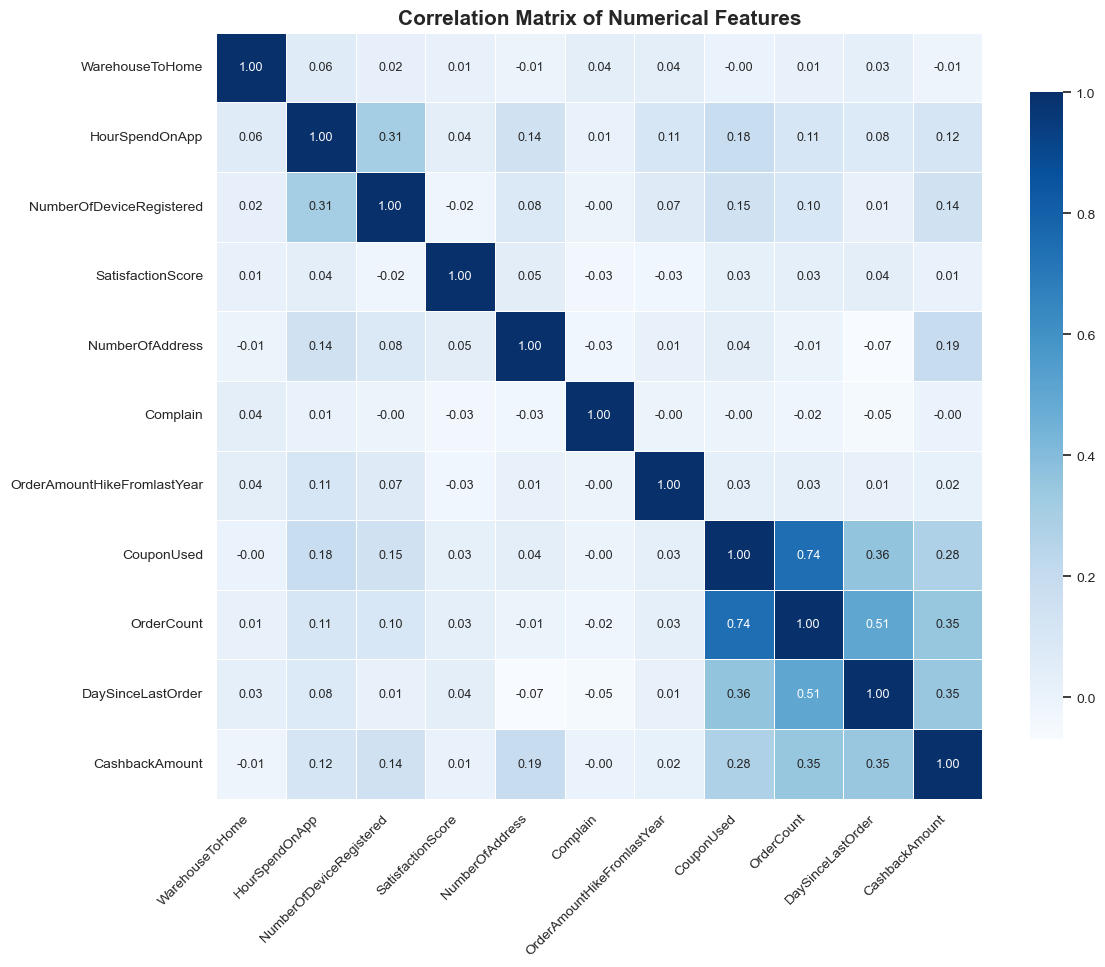

In [32]:
corr_matrix = df[NUMERIC_COLS].corr()

plt.figure(figsize=(12, 10))  # tăng kích thước

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    square=True,
    linewidths=0.5,
    annot_kws={"size": 9},   # giảm size số trong ô
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix of Numerical Features", fontsize=15, fontweight="bold")

# Xoay label cho đẹp
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [33]:
corr_pairs = (
    corr_matrix.where(~np.tril(np.ones(corr_matrix.shape)).astype(bool))
    .stack()
    .sort_values(key=abs, ascending=False)
)

print("Top correlated feature pairs:")
display(corr_pairs.head(10))

Top correlated feature pairs:


CouponUsed                OrderCount                  0.742004
OrderCount                DaySinceLastOrder           0.506580
CouponUsed                DaySinceLastOrder           0.362920
OrderCount                CashbackAmount              0.352843
DaySinceLastOrder         CashbackAmount              0.348568
HourSpendOnApp            NumberOfDeviceRegistered    0.308218
CouponUsed                CashbackAmount              0.276430
NumberOfAddress           CashbackAmount              0.186202
HourSpendOnApp            CouponUsed                  0.184532
NumberOfDeviceRegistered  CouponUsed                  0.147626
dtype: float64

***
Danh sách các cặp biến có tương quan cao nhất cho thấy một số mối liên hệ đáng chú ý trong hành vi mua sắm của khách hàng. Trong đó, cặp **CouponUsed** và **OrderCount** có hệ số tương quan cao nhất, đạt **0,742004**. Mức tương quan này cho thấy khách hàng đặt hàng nhiều hơn thường cũng có xu hướng sử dụng coupon nhiều hơn, phản ánh mối liên hệ khá chặt giữa tần suất mua hàng và hành vi sử dụng khuyến mãi.

Cặp **OrderCount** và **DaySinceLastOrder** có hệ số tương quan **0,506580**, cho thấy giữa số lượng đơn hàng và thời gian kể từ lần đặt hàng gần nhất tồn tại mối liên hệ ở mức tương đối rõ. Bên cạnh đó, **CouponUsed** và **DaySinceLastOrder** cũng có tương quan dương ở mức **0,362920**. Điều này gợi ý rằng các biến liên quan đến tần suất mua hàng, mức độ tương tác gần đây và hành vi sử dụng ưu đãi có xu hướng liên kết với nhau.

Một số cặp biến khác cũng đáng chú ý như:
- **OrderCount** và **CashbackAmount**: **0,352843**
- **DaySinceLastOrder** và **CashbackAmount**: **0,348568**
- **HourSpendOnApp** và **NumberOfDeviceRegistered**: **0,308218**
- **CouponUsed** và **CashbackAmount**: **0,276430**

Các mối liên hệ này cho thấy hành vi khách hàng trên nền tảng không diễn ra tách rời, mà có sự gắn kết nhất định giữa mức độ mua sắm, mức độ sử dụng ưu đãi, giá trị hoàn tiền và tần suất tương tác với ứng dụng.

Dù vậy, ngoài cặp **CouponUsed – OrderCount** có tương quan khá cao, phần lớn các cặp biến còn lại chỉ dừng ở mức thấp đến trung bình. Điều này cho thấy dữ liệu không xuất hiện quá nhiều mối liên hệ tuyến tính mạnh giữa các biến.

Khi đặt kết quả này cùng với các biểu đồ phân phối đã phân tích trước đó, có thể thấy rằng mối quan hệ giữa hành vi khách hàng và khả năng churn nhiều khả năng không chỉ dừng ở dạng tuyến tính đơn giản. Vì vậy, nếu chỉ sử dụng các mô hình tuyến tính thì có thể chưa khai thác hết cấu trúc dữ liệu. Đây cũng là cơ sở hợp lý để lựa chọn các mô hình có khả năng học tốt hơn trên dữ liệu bảng và nắm bắt các tương tác phức tạp giữa các biến, chẳng hạn như **TabNet**.
***

**6. Feature Importance** 

In [34]:
X_train_final = pd.read_csv("artifacts/data/X_train_final.csv")
X_val_final = pd.read_csv("artifacts/data/X_val_final.csv")

y_train = pd.read_csv("artifacts/data/y_train.csv").squeeze()
y_val = pd.read_csv("artifacts/data/y_val.csv").squeeze()

with open("artifacts/data/meta.json", "r", encoding="utf-8") as f:
    meta = json.load(f)

FINAL_COLS = meta["FINAL_COLS"]

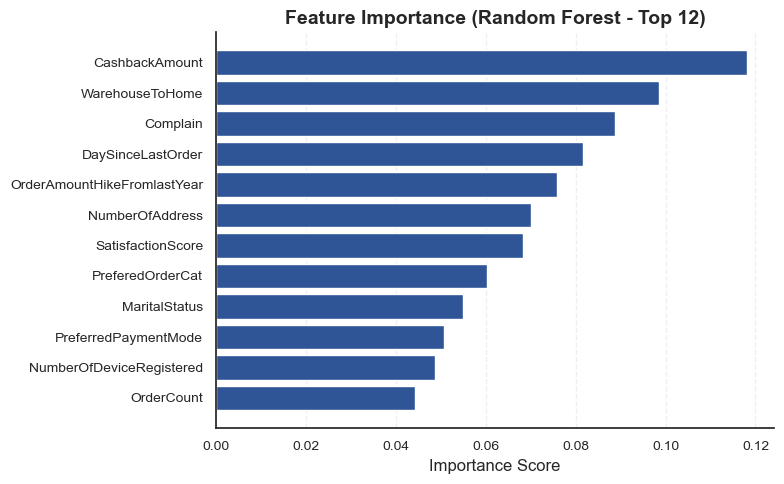

CashbackAmount                 0.118220
WarehouseToHome                0.098519
Complain                       0.088696
DaySinceLastOrder              0.081536
OrderAmountHikeFromlastYear    0.075925
NumberOfAddress                0.070065
SatisfactionScore              0.068280
PreferedOrderCat               0.060355
MaritalStatus                  0.054889
PreferredPaymentMode           0.050743
NumberOfDeviceRegistered       0.048603
OrderCount                     0.044150
CityTier                       0.037102
CouponUsed                     0.036859
HourSpendOnApp                 0.023042
Gender                         0.022979
PreferredLoginDevice           0.020036
dtype: float64

In [35]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf.fit(X_train_final, y_train)

importances = pd.Series(rf.feature_importances_, index=FINAL_COLS).sort_values(ascending=False)

# Plot top 12
top_n = 12
top_imp = importances.head(top_n)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_imp.index[::-1], top_imp.values[::-1], color="#2F5597")
ax.set_title("Feature Importance (Random Forest - Top 12)", fontweight="bold")
ax.set_xlabel("Importance Score")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

display(importances.head(20))

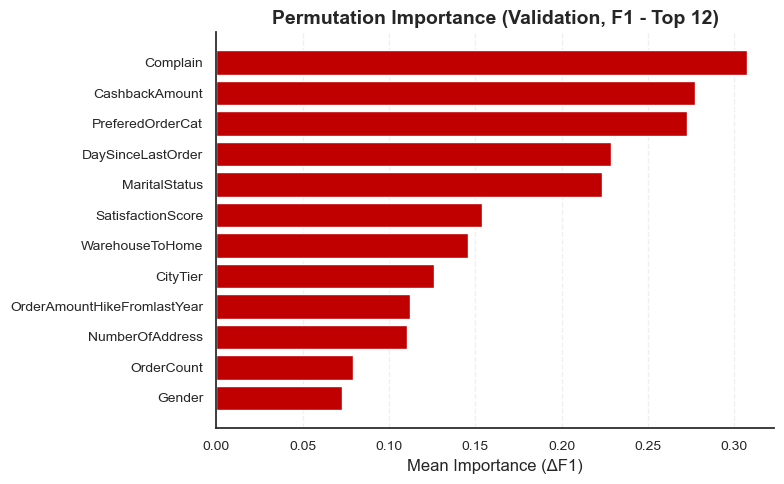

Complain                       0.307645
CashbackAmount                 0.277486
PreferedOrderCat               0.272638
DaySinceLastOrder              0.228716
MaritalStatus                  0.223320
SatisfactionScore              0.153926
WarehouseToHome                0.145593
CityTier                       0.125881
OrderAmountHikeFromlastYear    0.112046
NumberOfAddress                0.110441
OrderCount                     0.079154
Gender                         0.072796
PreferredPaymentMode           0.071195
NumberOfDeviceRegistered       0.067706
PreferredLoginDevice           0.054567
HourSpendOnApp                 0.017465
CouponUsed                     0.008376
dtype: float64

In [36]:
perm = permutation_importance(
    rf,
    X_val_final,
    y_val,
    n_repeats=10,
    random_state=42,
    scoring="f1"
)

perm_imp = pd.Series(perm.importances_mean, index=FINAL_COLS).sort_values(ascending=False)

top_n = 12
top_perm = perm_imp.head(top_n)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_perm.index[::-1], top_perm.values[::-1], color="#C00000")
ax.set_title("Permutation Importance (Validation, F1 - Top 12)", fontweight="bold")
ax.set_xlabel("Mean Importance (ΔF1)")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

display(perm_imp.head(20))

***
Kết quả đánh giá mức độ quan trọng của biến cho thấy một số đặc trưng có đóng góp nổi bật hơn trong việc phân biệt giữa khách hàng churn và không churn. Trong phần giá trị hiển thị, **Complain** là biến có mức quan trọng cao nhất với **0,307645**, tiếp theo là **CashbackAmount** (**0,277486**) và **PreferedOrderCat** (**0,272638**). Sau đó là **DaySinceLastOrder** (**0,228716**) và **MaritalStatus** (**0,223320**).

Các biến như **SatisfactionScore** (**0,153926**), **WarehouseToHome** (**0,145593**), **CityTier** (**0,125881**), **OrderAmountHikeFromlastYear** (**0,112046**) và **NumberOfAddress** (**0,110441**) cũng cho thấy mức ảnh hưởng nhất định. Điều này cho thấy khả năng churn không chỉ liên quan đến hành vi mua hàng gần đây mà còn chịu tác động bởi trải nghiệm dịch vụ, đặc điểm khách hàng và yếu tố giao dịch.

Trong khi đó, một số biến hành vi thường được chú ý như **OrderCount** (**0,079154**), **HourSpendOnApp** (**0,017465**) và **CouponUsed** (**0,008376**) lại có mức quan trọng thấp hơn trong kết quả này. Điều đó cho thấy khi xét riêng ở giai đoạn khám phá dữ liệu, không phải biến hành vi nào cũng tạo ra sức phân biệt mạnh đối với churn.

Kết quả này cũng gợi ý rằng các yếu tố liên quan đến **khiếu nại**, **giá trị hoàn tiền**, **danh mục mua sắm ưa thích**, **thời gian kể từ lần đặt hàng gần nhất** và **tình trạng hôn nhân** đang mang nhiều thông tin hơn cho bài toán dự đoán churn trong bộ dữ liệu hiện tại.

Phần đánh giá này được thực hiện ở mức **EDA-level**, nên chủ yếu mang ý nghĩa định hướng ban đầu cho việc lựa chọn và diễn giải biến. Ở các giai đoạn mô hình hóa tiếp theo, mức độ quan trọng của biến cần được kiểm chứng lại bằng mô hình dự đoán chính để có kết luận chắc chắn hơn về vai trò thực sự của từng đặc trưng.
***

**7. Cohort Tenure (retention/churn theo nhóm)** 

In [42]:
df["DaySinceLastOrder_Group"] = pd.cut(
    df["DaySinceLastOrder"],
    bins=[0, 3, 6, 9, 12, df["DaySinceLastOrder"].max()],
    labels=["0-3", "4-6", "7-", "10-12", "13+"],
    include_lowest=True
)

In [43]:
cohort_churn = (
    df.groupby("DaySinceLastOrder_Group")[TARGET_COL]
    .agg(["count", "sum", "mean"])
)

cohort_churn["Churn Rate (%)"] = cohort_churn["mean"] * 100

display(cohort_churn.round(2))

,count,sum,mean,Churn Rate (%)
DaySinceLastOrder_Group,,,,
0-3,2502,524,0.21,20.94
4-6,681,88,0.13,12.92
7-,1177,147,0.12,12.49
10-12,286,19,0.07,6.64
13+,133,8,0.06,6.02


In [44]:
cohort_churn["Retention Rate (%)"] = 100 - cohort_churn["Churn Rate (%)"]

display(cohort_churn[["Churn Rate (%)", "Retention Rate (%)"]].round(2))

,Churn Rate (%),Retention Rate (%)
DaySinceLastOrder_Group,,
0-3,20.94,79.06
4-6,12.92,87.08
7-,12.49,87.51
10-12,6.64,93.36
13+,6.02,93.98


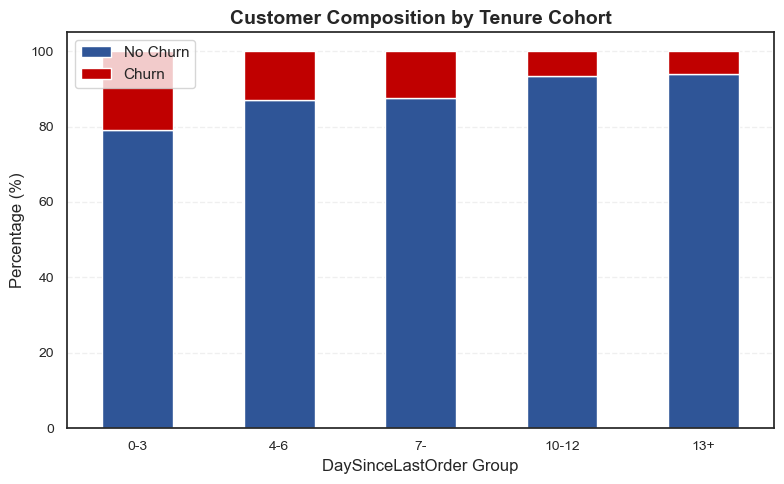

In [48]:
cohort_dist = pd.crosstab(df["DaySinceLastOrder_Group"], df[TARGET_COL], normalize='index') * 100

cohort_dist.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5),
    color=["#2F5597", "#C00000"]
)

plt.title("Customer Composition by Tenure Cohort", fontweight="bold")
plt.ylabel("Percentage (%)")
plt.xlabel("DaySinceLastOrder Group")
plt.legend(["No Churn", "Churn"])
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

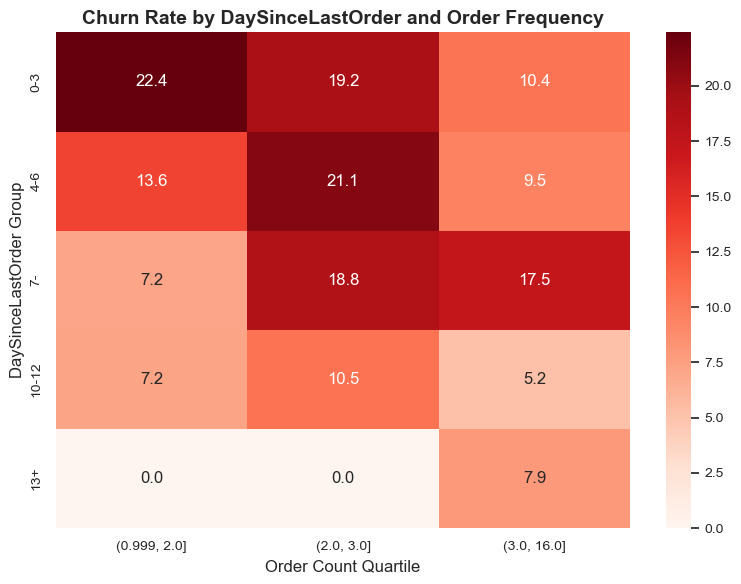

In [51]:
df["OrderCount_bin"] = pd.qcut(df["OrderCount"], q=4, duplicates='drop')

pivot = pd.pivot_table(
    df,
    values=TARGET_COL,
    index="DaySinceLastOrder_Group",
    columns="OrderCount_bin",
    aggfunc="mean"
) * 100

plt.figure(figsize=(8,6))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".1f",
    cmap="Reds"
)

plt.title("Churn Rate by DaySinceLastOrder and Order Frequency", fontweight="bold")
plt.ylabel("DaySinceLastOrder Group")
plt.xlabel("Order Count Quartile")
plt.tight_layout()
plt.show()

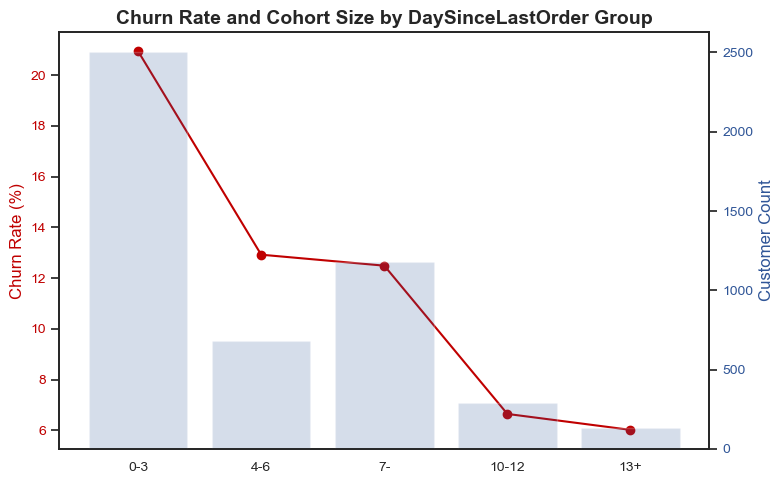

In [50]:
fig, ax1 = plt.subplots(figsize=(8,5))

ax1.plot(
    cohort_churn.index.astype(str),
    cohort_churn["Churn Rate (%)"],
    marker="o",
    color="#C00000"
)
ax1.set_ylabel("Churn Rate (%)", color="#C00000")
ax1.tick_params(axis='y', labelcolor="#C00000")

ax2 = ax1.twinx()
ax2.bar(
    cohort_churn.index.astype(str),
    cohort_churn["count"],
    alpha=0.2,
    color="#2F5597"
)
ax2.set_ylabel("Customer Count", color="#2F5597")
ax2.tick_params(axis='y', labelcolor="#2F5597")

plt.title("Churn Rate and Cohort Size by DaySinceLastOrder Group", fontweight="bold")
plt.tight_layout()
plt.show()

***
The cohort analysis shows a clear relationship between tenure and churn behavior.

Biểu đồ kết hợp giữa cột và đường cho thấy sự thay đổi đồng thời của **quy mô khách hàng** và **tỷ lệ churn** giữa các nhóm trên trục hoành. Trong đó, cột thể hiện số lượng khách hàng của từng nhóm, còn đường màu đỏ phản ánh tỷ lệ churn tương ứng.

Nhóm **0–3** có quy mô khách hàng lớn nhất, vào khoảng **2.500 khách hàng**, đồng thời cũng có tỷ lệ churn cao nhất, xấp xỉ **21%**. Điều này cho thấy rủi ro rời bỏ tập trung khá mạnh ở nhóm khách hàng thuộc giai đoạn đầu của phân nhóm được xét.

Sang các nhóm tiếp theo, tỷ lệ churn giảm đáng kể. Cụ thể, nhóm **4–6** có churn rate khoảng **13%**, nhóm **7–9** vào khoảng **12,5%**, trong khi nhóm **10–12** và **13+** chỉ còn lần lượt khoảng **6,7%** và **6,0%**. Xu hướng này cho thấy khi khách hàng dịch chuyển sang các nhóm sau, khả năng rời bỏ có xu hướng giảm.

Về quy mô, số lượng khách hàng cũng giảm dần theo từng nhóm. Sau nhóm **0–3**, các cohort còn lại có quy mô nhỏ hơn khá rõ, đặc biệt là các nhóm **10–12** và **13+**. Điều này cho thấy phần lớn khách hàng tập trung ở các nhóm đầu, trong khi số lượng khách hàng ở các nhóm sau ít hơn đáng kể.

Biểu đồ này gợi ý rằng rủi ro churn không phân bố đồng đều giữa các nhóm khách hàng. Nhóm đầu tiên vừa có quy mô lớn vừa có tỷ lệ churn cao, nên đây là nhóm cần được ưu tiên trong các hoạt động chăm sóc, nhắc mua lại hoặc triển khai chương trình giữ chân khách hàng.
***

**8. EDA Insight Summary**

### 1. Tổng quan về cấu trúc dữ liệu

Bộ dữ liệu cho thấy sự mất cân bằng lớp ở mức vừa phải, khi tỷ lệ khách hàng rời bỏ chiếm khoảng **16–17%** tổng số quan sát. Mức chênh lệch này chưa quá nghiêm trọng, nhưng vẫn đủ để khiến chỉ số **accuracy** trở nên kém đại diện nếu được sử dụng đơn lẻ. Vì vậy, trong giai đoạn xây dựng mô hình, nghiên cứu ưu tiên các thước đo như **F1-score** và **Recall** nhằm phản ánh tốt hơn khả năng nhận diện đúng nhóm khách hàng có nguy cơ rời bỏ.

---

### 2. Hành vi tương tác là nhóm yếu tố có ảnh hưởng quan trọng

Kết quả phân tích khám phá cho thấy các biến phản ánh mức độ tương tác và hành vi mua sắm của khách hàng, như **DaySinceLastOrder**, **OrderCount**, **CouponUsed** và **HourSpendOnApp**, đều có liên hệ nhất định với trạng thái churn.

So với nhóm không rời bỏ, khách hàng churn thường có một số đặc điểm dễ nhận thấy hơn, bao gồm khoảng cách giữa các lần giao dịch dài hơn, tần suất mua hàng thấp hơn và mức độ tương tác với nền tảng kém hơn. Điều này cho thấy churn không phải là một hiện tượng xảy ra ngẫu nhiên, mà thường hình thành sau một quá trình suy giảm dần trong mức độ gắn kết của khách hàng với doanh nghiệp.

---

### 3. Vai trò của mức độ mua hàng gần đây

Phân tích theo các nhóm **DaySinceLastOrder** cho thấy tỷ lệ churn thay đổi khá rõ giữa các nhóm khách hàng. Những khách hàng có khoảng thời gian kể từ lần mua gần nhất ở mức cao thường có nguy cơ rời bỏ lớn hơn so với các nhóm còn lại.

Kết quả này cho thấy **DaySinceLastOrder** là một biến phản ánh khá tốt mức độ duy trì tương tác gần đây của khách hàng. Khi thời gian không phát sinh giao dịch kéo dài, khả năng khách hàng rời bỏ nền tảng cũng có xu hướng tăng lên. Điều đó cho thấy recency không chỉ là đặc trưng hành vi đơn thuần mà còn là tín hiệu cảnh báo sớm đối với churn.

---

### 4. Tác động tương tác giữa các biến hành vi

Phân tích heatmap hai chiều giữa **DaySinceLastOrder** và **OrderCount** cho thấy rủi ro churn cao hơn ở những nhóm khách hàng có mức độ mua hàng thấp và không duy trì giao dịch thường xuyên. Điều này cho thấy ảnh hưởng của từng biến riêng lẻ là chưa đủ để giải thích đầy đủ hành vi rời bỏ.

Nói cách khác, churn chịu tác động từ **sự kết hợp giữa các đặc trưng hành vi**, thay vì chỉ phụ thuộc vào một yếu tố đơn lẻ. Đây là dấu hiệu cho thấy cấu trúc dữ liệu mang tính **phi tuyến** và có sự tương tác giữa các biến.

---

### 5. Vai trò của các biến phân loại

Bên cạnh các biến hành vi, một số biến phân loại như **phương thức thanh toán**, **thiết bị đăng nhập** và **city tier** cũng cho thấy sự khác biệt nhất định về tỷ lệ churn giữa các nhóm khách hàng.

Điều này cho thấy hành vi rời bỏ không chỉ bị chi phối bởi hoạt động giao dịch, mà còn liên quan đến bối cảnh sử dụng dịch vụ, đặc điểm thị trường và cách khách hàng tương tác với nền tảng. Những yếu tố này giúp mở rộng góc nhìn phân tích, đồng thời bổ sung thêm thông tin có giá trị cho mô hình dự đoán.

---

### 6. Hàm ý đối với lựa chọn mô hình

Mặc dù hệ số tương quan tuyến tính giữa các biến trong bộ dữ liệu không quá mạnh, các phân tích về phân phối, nhóm hành vi và tương tác biến lại cho thấy dữ liệu có cấu trúc khá phức tạp. Nhiều mối quan hệ quan trọng dường như không thể được mô tả đầy đủ bằng các mô hình tuyến tính đơn giản.

Điều này gợi ý rằng các phương pháp tuyến tính có thể chưa khai thác hết thông tin tiềm ẩn trong dữ liệu. Vì vậy, nghiên cứu cần đến những mô hình có khả năng xử lý tốt dữ liệu dạng bảng và học được các tương tác đặc trưng phức tạp. Đây cũng là cơ sở hợp lý cho việc lựa chọn **TabNet** ở giai đoạn tiếp theo, kết hợp với **PSO** để tối ưu siêu tham số.

---

### 7. Hàm ý quản trị

Từ các kết quả EDA, có thể rút ra một số định hướng quản trị quan trọng. Trước hết, doanh nghiệp cần đặc biệt quan tâm đến những khách hàng đã có dấu hiệu **giãn cách mua hàng**, vì đây là nhóm có nguy cơ churn cao hơn.

Bên cạnh đó, việc xây dựng hệ thống cảnh báo sớm dựa trên các dấu hiệu như **tần suất giao dịch giảm**, **số ngày kể từ lần mua gần nhất tăng lên** hoặc **mức độ tương tác thấp** là cần thiết để phát hiện sớm nhóm khách hàng có nguy cơ rời bỏ.

Cuối cùng, doanh nghiệp nên triển khai các biện pháp nhằm thúc đẩy mua lại và gia tăng tương tác, chẳng hạn như cá nhân hóa ưu đãi, nhắc mua lại đúng thời điểm và cải thiện trải nghiệm sử dụng trên nền tảng. Những giải pháp này không chỉ giúp giảm churn mà còn góp phần nâng cao giá trị vòng đời khách hàng trong dài hạn.